In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA = PROJECT_ROOT / "data" / "processed"

df = pd.read_parquet(DATA)
flights = df.loc[(df["Cancelled"] == False) & (df["Diverted"] == False), :].copy().reset_index(drop=True)
flights["y"] = flights["ArrDelay"].ge(15).astype(int)

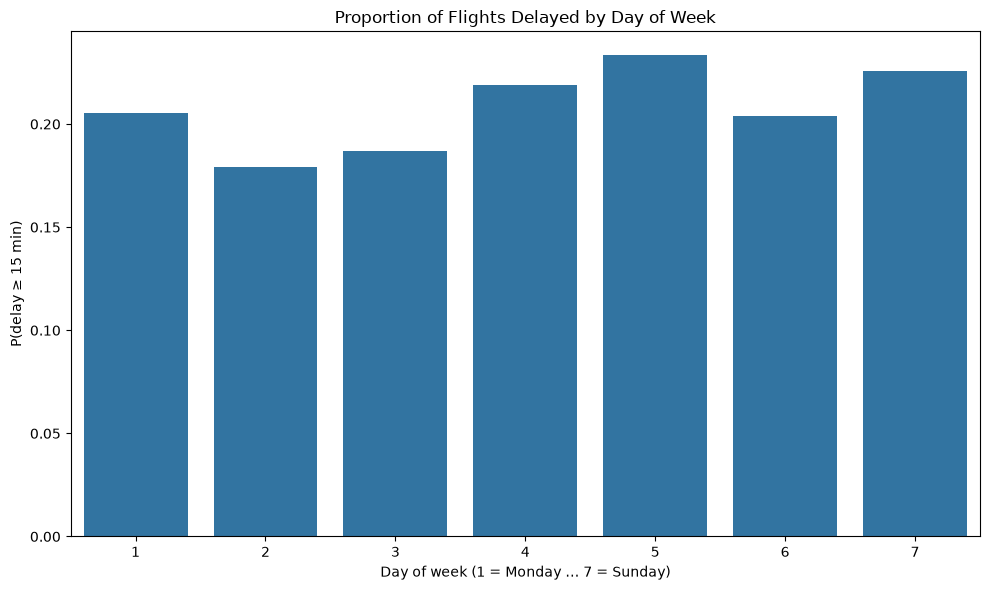

In [2]:
flights.groupby("DayOfWeek")["y"].mean().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x="DayOfWeek", y="y", data=flights, errorbar=None)
plt.title("Proportion of Flights Delayed by Day of Week")
plt.ylabel("P(delay ≥ 15 min)")
plt.xlabel("Day of week (1 = Monday … 7 = Sunday)")
plt.tight_layout()
plt.show()

Little to no difference in delay rate across days of the week.

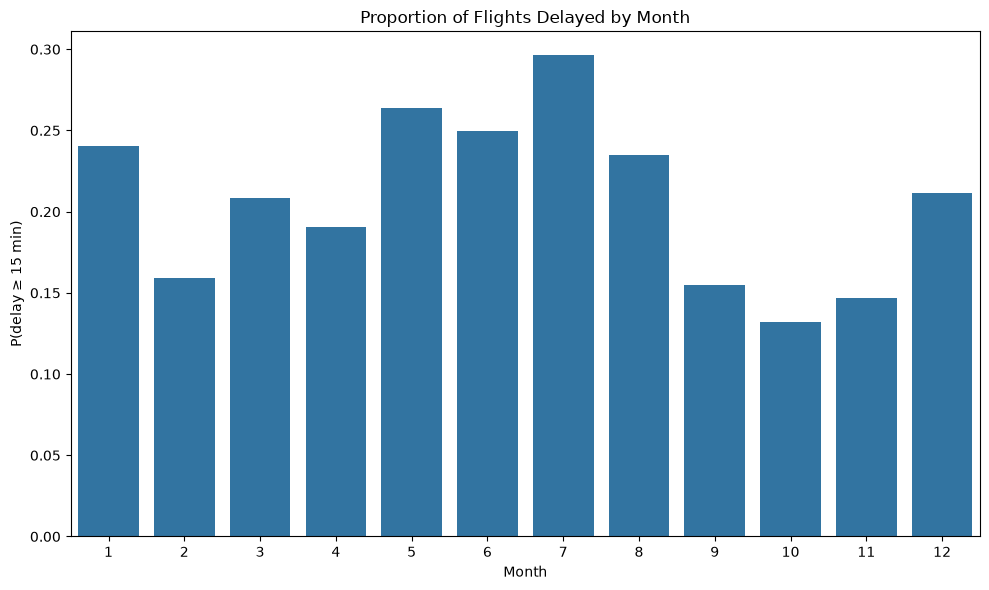

In [3]:
flights.groupby("Month")["y"].mean().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x="Month", y="y", data=flights, errorbar=None)
plt.title("Proportion of Flights Delayed by Month")
plt.ylabel("P(delay ≥ 15 min)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

Higher delay rates in winter and summer.

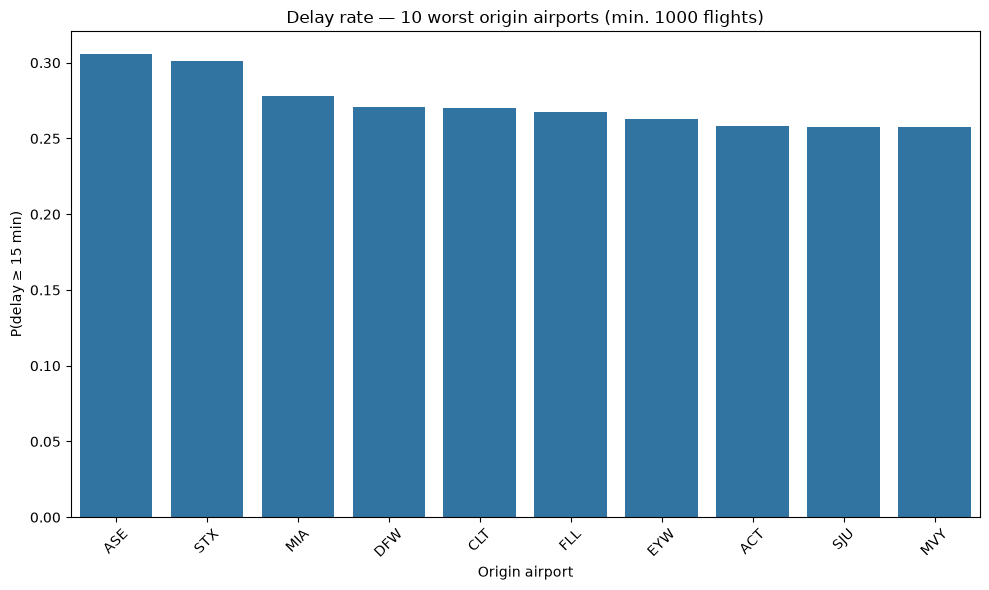

In [4]:
MIN_FLIGHTS = 1000

by_origin = flights.groupby("Origin", observed=True)["y"].agg(["mean", "size"])
by_origin = by_origin[by_origin["size"] >= MIN_FLIGHTS]

worst = by_origin["mean"].sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=worst.index.astype(str), y=worst.values, errorbar=None)
plt.title("Delay rate — 10 worst origin airports (min. 1000 flights)")
plt.ylabel("P(delay ≥ 15 min)")
plt.xlabel("Origin airport")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

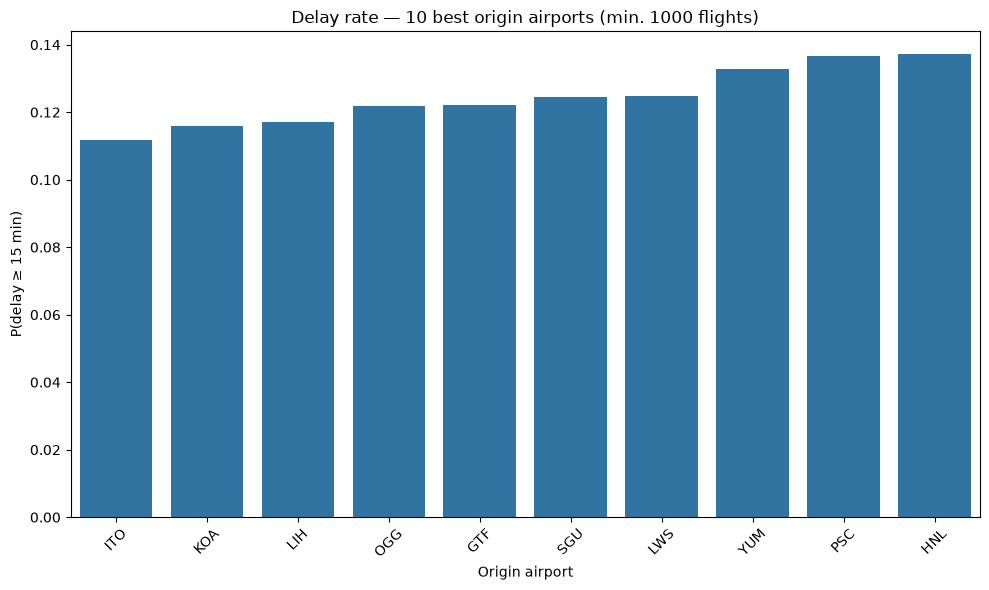

In [5]:
MIN_FLIGHTS = 1000

by_origin = flights.groupby("Origin", observed=True)["y"].agg(["mean", "size"])
by_origin = by_origin[by_origin["size"] >= MIN_FLIGHTS]

best = by_origin["mean"].sort_values(ascending=True).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=best.index.astype(str), y=best.values, errorbar=None)
plt.title("Delay rate — 10 best origin airports (min. 1000 flights)")
plt.ylabel("P(delay ≥ 15 min)")
plt.xlabel("Origin airport")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

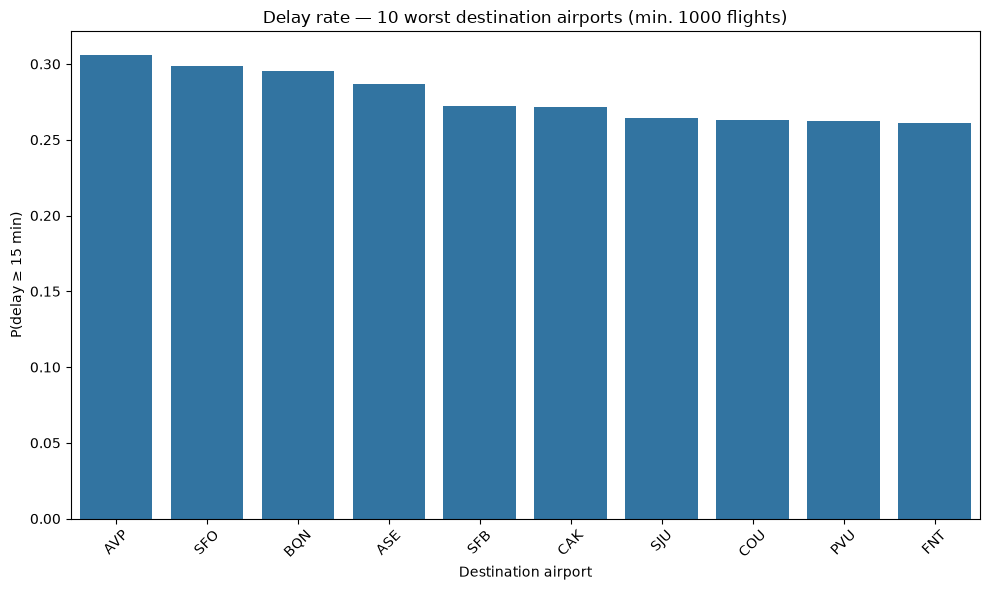

In [6]:
MIN_FLIGHTS = 1000

by_dest = flights.groupby("Dest", observed=True)["y"].agg(["mean", "size"])
by_dest = by_dest[by_dest["size"] >= MIN_FLIGHTS]

worst = by_dest["mean"].sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=worst.index.astype(str), y=worst.values, errorbar=None)
plt.title("Delay rate — 10 worst destination airports (min. 1000 flights)")
plt.ylabel("P(delay ≥ 15 min)")
plt.xlabel("Destination airport")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

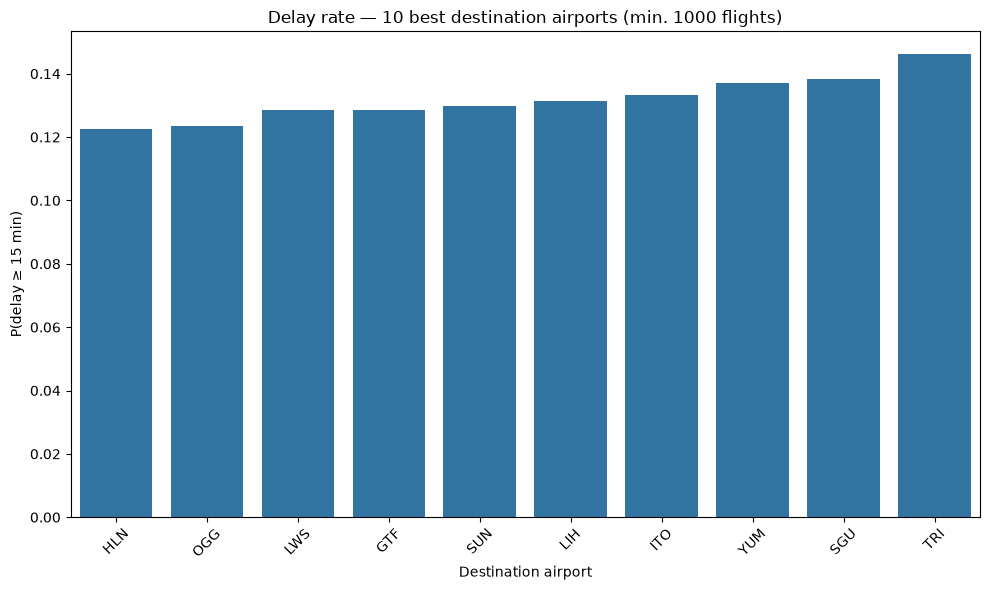

In [7]:
MIN_FLIGHTS = 1000

by_dest = flights.groupby("Dest", observed=True)["y"].agg(["mean", "size"])
by_dest = by_dest[by_dest["size"] >= MIN_FLIGHTS]

best = by_dest["mean"].sort_values(ascending=True).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=best.index.astype(str), y=best.values, errorbar=None)
plt.title("Delay rate — 10 best destination airports (min. 1000 flights)")
plt.ylabel("P(delay ≥ 15 min)")
plt.xlabel("Destination airport")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

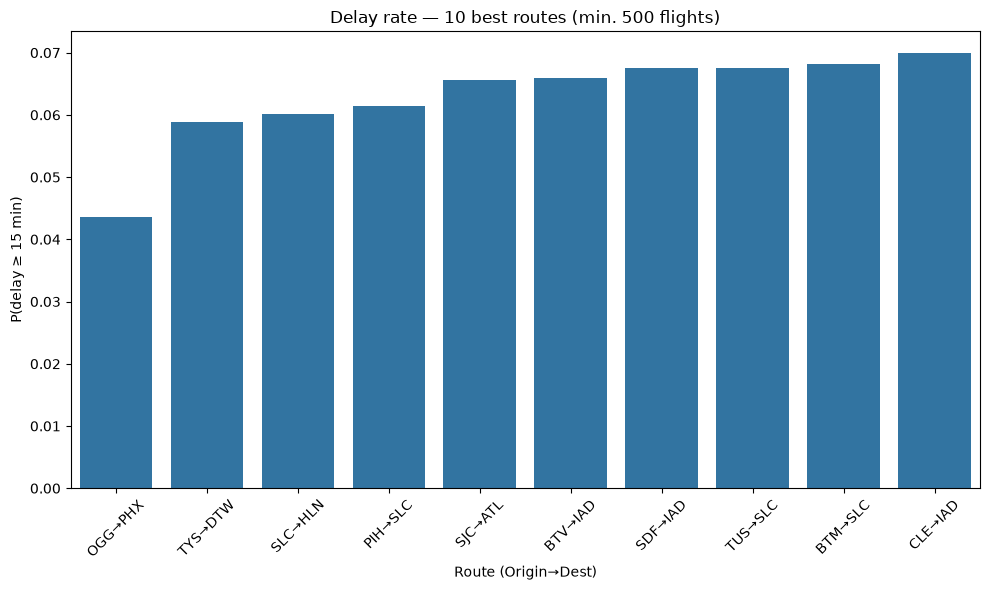

In [8]:
MIN_FLIGHTS = 500

by_route = flights.groupby(["Origin", "Dest"], observed=True)["y"].agg(["mean", "size"])
by_route = by_route[by_route["size"] >= MIN_FLIGHTS]

best = by_route["mean"].sort_values(ascending=True).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=best.index.map(lambda r: f"{r[0]}→{r[1]}"), y=best.values, errorbar=None)
plt.title("Delay rate — 10 best routes (min. 500 flights)")
plt.ylabel("P(delay ≥ 15 min)")
plt.xlabel("Route (Origin→Dest)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

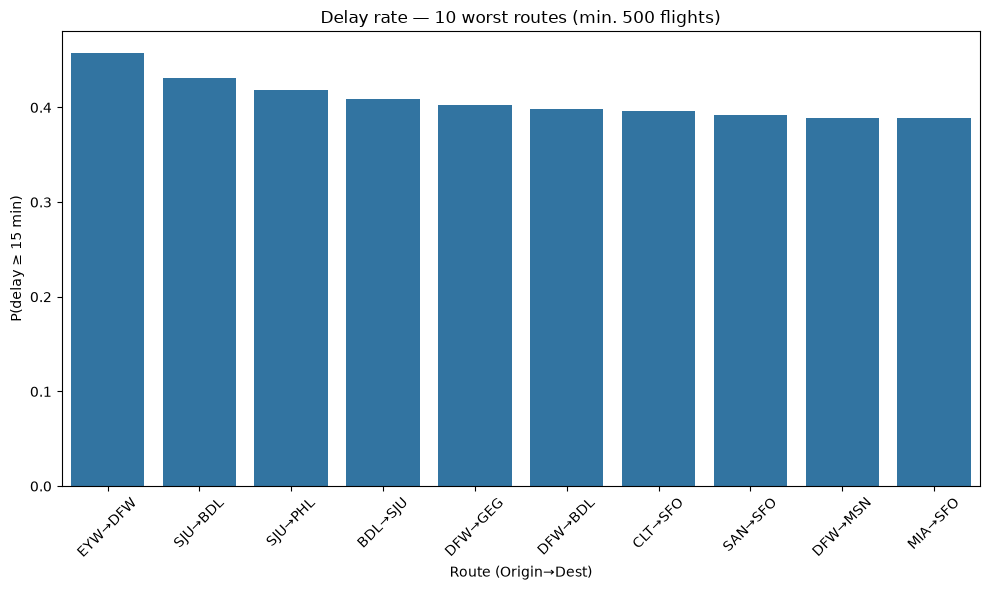

In [9]:
MIN_FLIGHTS = 500

by_route = flights.groupby(["Origin", "Dest"], observed=True)["y"].agg(["mean", "size"])
by_route = by_route[by_route["size"] >= MIN_FLIGHTS]

worst = by_route["mean"].sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=worst.index.map(lambda r: f"{r[0]}→{r[1]}"), y=worst.values, errorbar=None)
plt.title("Delay rate — 10 worst routes (min. 500 flights)")
plt.ylabel("P(delay ≥ 15 min)")
plt.xlabel("Route (Origin→Dest)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
flights.columns

Index(['Month', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'Tail_Number',
       'Origin', 'OriginState', 'Dest', 'DestState', 'CRSDepTime', 'DepDelay',
       'DepDelayMinutes', 'DepDel15', 'TaxiOut', 'TaxiIn', 'CRSArrTime',
       'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'Cancelled',
       'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime',
       'AirTime', 'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay',
       'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'y'],
      dtype='str')

In [11]:
flights["CRSDepTime"].max() 

np.int16(2400)

In [13]:
flights["DepHour"] = flights["CRSDepTime"] // 100
flights["DepHour"] = flights["DepHour"].replace(24, 0)

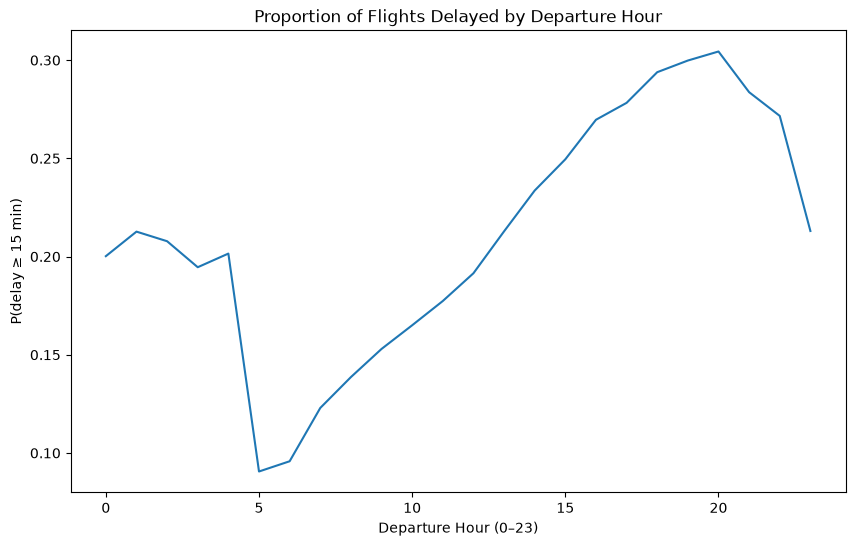

In [17]:
plt.figure(figsize=(10,6))
sns.lineplot(x="DepHour", y="y", data=flights.groupby("DepHour")["y"].mean().reset_index())
plt.title("Proportion of Flights Delayed by Departure Hour")
plt.ylabel("P(delay ≥ 15 min)")
plt.xlabel("Departure Hour (0–23)")
plt.show()

We can see that most of delayed flights starts in the evening/night with the lowest part in early morning hours.

C:\Users\micae\AppData\Local\Temp\ipykernel_7712\3473726805.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


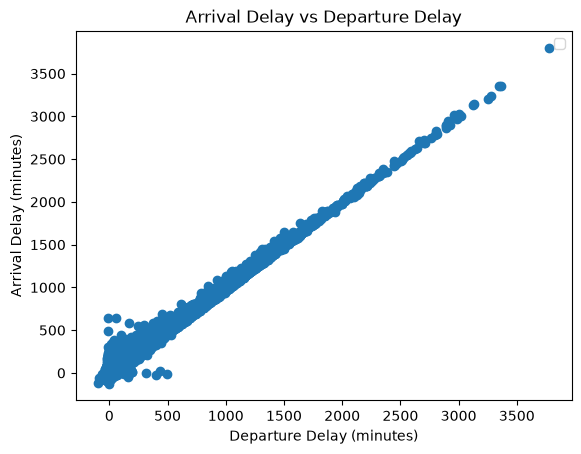

In [22]:
import numpy as np
plt.scatter(flights["DepDelay"], flights["ArrDelay"])
plt.title("Arrival Delay vs Departure Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.legend()
plt.show()

In [ ]:
flights.groupby("CarrierD")

In [23]:
causes = ["CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"]
delayed = flights[flights["y"] == 1]

In [ ]:
flights[causes].notna().mean()                                   
(delayed[causes].sum(axis=1) - delayed["ArrDelayMinutes"]).abs().max()

np.float32(180.0)

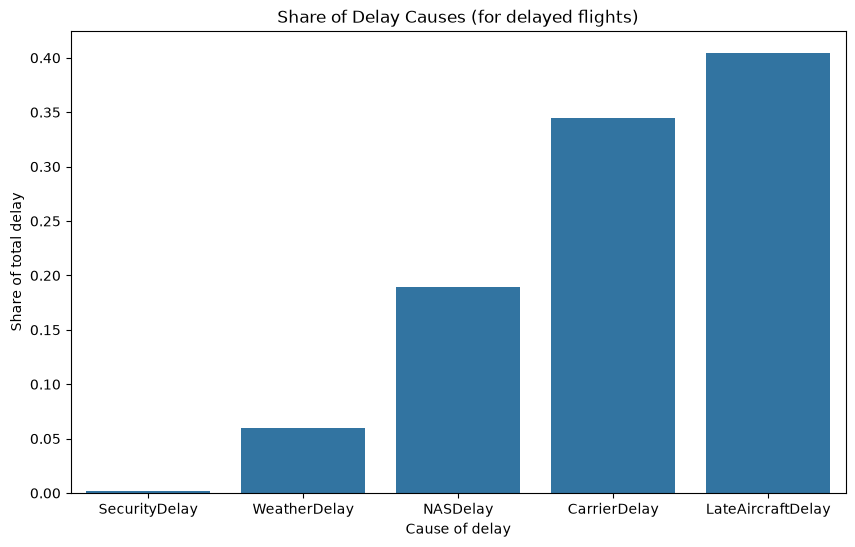

In [26]:
share = delayed[causes].sum() / delayed[causes].sum().sum()
share = share.sort_values(ascending=True)
plt.figure(figsize=(10, 6))
sns.barplot(x=share.index, y=share.values, errorbar=None)
plt.title("Share of Delay Causes (for delayed flights)")
plt.ylabel("Share of total delay")
plt.xlabel("Cause of delay")
plt.show()

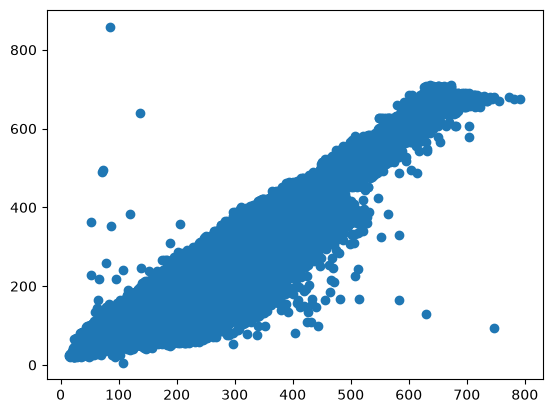

In [29]:
plt.scatter(flights["ActualElapsedTime"], flights["CRSElapsedTime"])
plt.title("Actual Elapsed Time vs Scheduled Elapsed Time")
plt.xlabel("Scheduled Elapsed Time (minutes)")
plt.ylabel("Actual Elapsed Time (minutes)")
plt.show()

In [30]:
faster = delayed[delayed["ArrDelay"]<delayed["DepDelay"]]
faster.shape[0] / delayed.shape[0]

0.5034387013212723

Even 50% of flights are making up some of the delay

<Axes: xlabel='DepHour', ylabel='Reporting_Airline'>

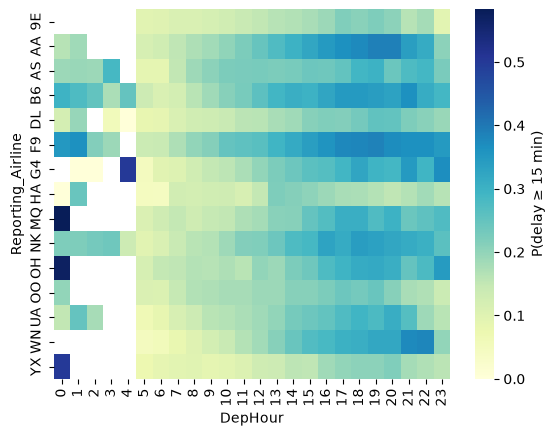

In [37]:
pivot = (flights.groupby(["Reporting_Airline", "DepHour"], observed=True)["y"]
                .mean()
                .unstack("DepHour"))
sns.heatmap(pivot, cmap="YlGnBu", cbar_kws={"label": "P(delay ≥ 15 min)"})

<Axes: xlabel='Month', ylabel='Reporting_Airline'>

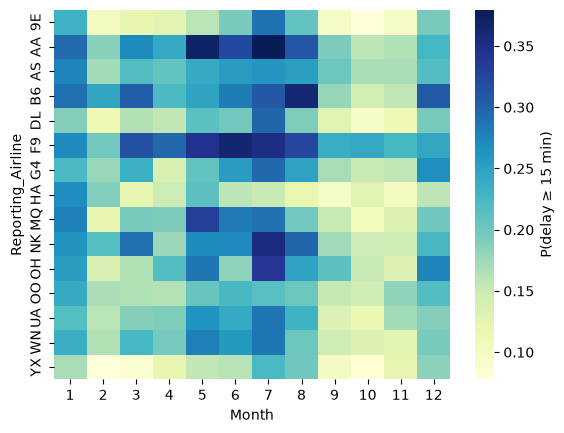

In [38]:
pivot = (flights.groupby(["Reporting_Airline", "Month"], observed=True)["y"]
                .mean()
                .unstack("Month"))
sns.heatmap(pivot, cmap="YlGnBu", cbar_kws={"label": "P(delay ≥ 15 min)"})

Bad airline means more delayed flights little difference in hour

<Axes: xlabel='Origin', ylabel='Reporting_Airline'>

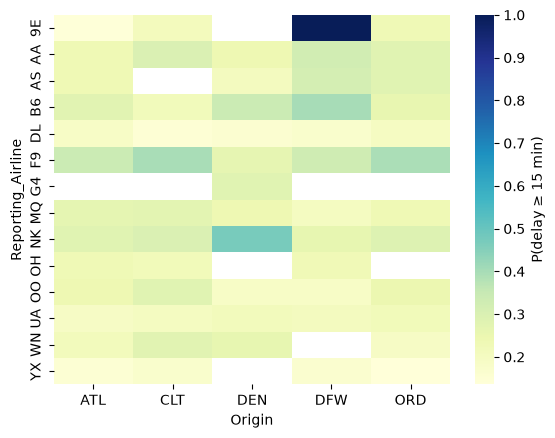

In [40]:
top_origins = flights["Origin"].value_counts().head(5).index    
subset = flights[flights["Origin"].isin(top_origins)]

pivot = (subset.groupby(["Reporting_Airline", "Origin"], observed=True)["y"]
               .mean()
               .unstack("Origin"))

sns.heatmap(pivot, cmap="YlGnBu", cbar_kws={"label": "P(delay ≥ 15 min)"})

<Axes: xlabel='Dest', ylabel='Reporting_Airline'>

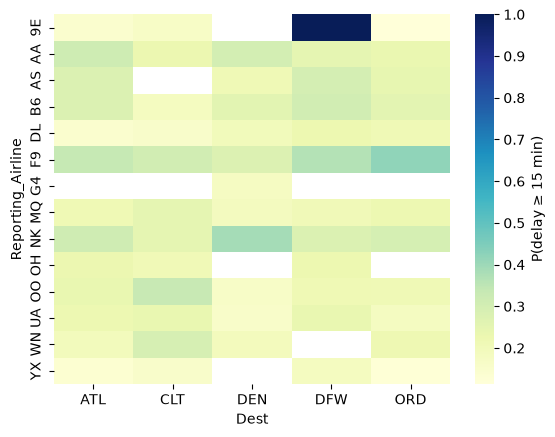

In [42]:
top_arrivals = flights["Dest"].value_counts().head(5).index    
subset = flights[flights["Dest"].isin(top_arrivals)]

pivot = (subset.groupby(["Reporting_Airline", "Dest"], observed=True)["y"]
               .mean()
               .unstack("Dest"))

sns.heatmap(pivot, cmap="YlGnBu", cbar_kws={"label": "P(delay ≥ 15 min)"})

<Axes: xlabel='Origin', ylabel='Reporting_Airline'>

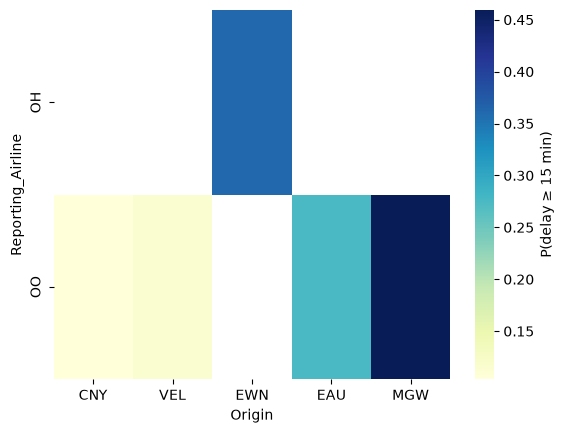

In [43]:
top_arrivals = flights["Origin"].value_counts().tail(5).index    
subset = flights[flights["Origin"].isin(top_arrivals)]

pivot = (subset.groupby(["Reporting_Airline", "Origin"], observed=True)["y"]
               .mean()
               .unstack("Origin"))

sns.heatmap(pivot, cmap="YlGnBu", cbar_kws={"label": "P(delay ≥ 15 min)"})

In [44]:
by_origin = flights.groupby("Origin", observed=True)["y"].agg(["mean", "size"])
by_origin = by_origin[by_origin["size"] >= 1000]

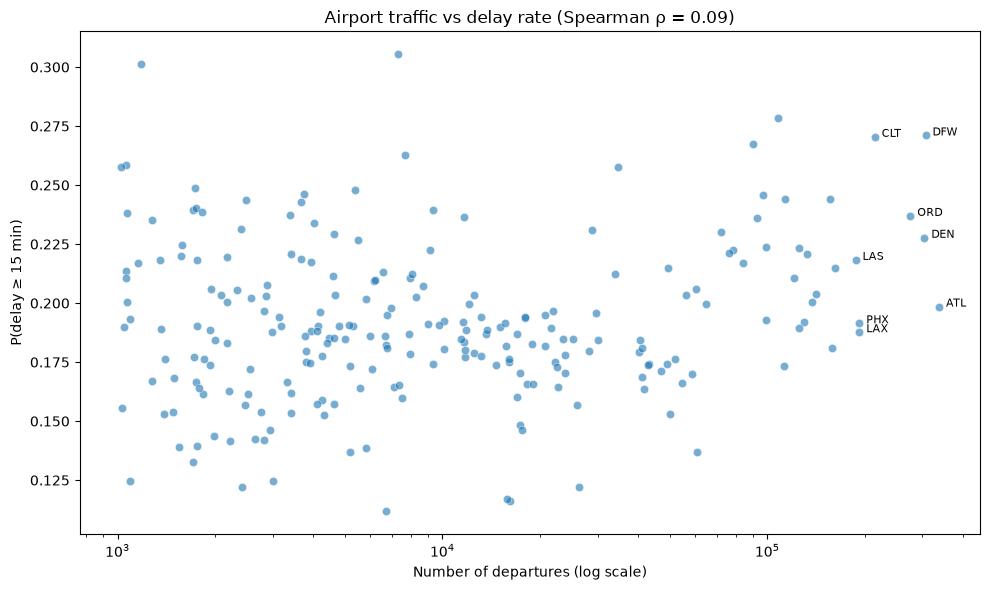

In [48]:

rho = by_origin["size"].corr(by_origin["mean"], method="spearman")

plt.figure(figsize=(10, 6))
sns.scatterplot(x="size", y="mean", data=by_origin, alpha=0.6)
plt.xscale("log")                                       
plt.title(f"Airport traffic vs delay rate (Spearman ρ = {rho:.2f})")
plt.xlabel("Number of departures (log scale)")
plt.ylabel("P(delay ≥ 15 min)")
for code, row in by_origin.nlargest(8, "size").iterrows():
    plt.annotate(str(code), (row["size"], row["mean"]),
                 xytext=(5, 0), textcoords="offset points", fontsize=8)

plt.tight_layout()
plt.show()

dropped (NaN): 0


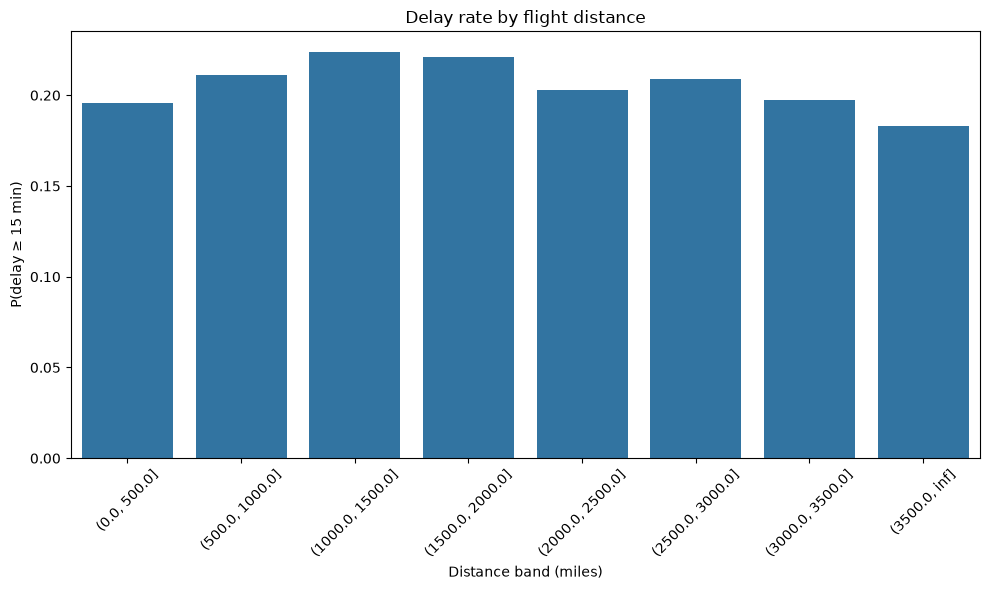

,mean,size
Distance_Binned,,
"(0.0, 500.0]",0.195543,2399939
"(500.0, 1000.0]",0.211322,2535067
"(1000.0, 1500.0]",0.224007,1131972
"(1500.0, 2000.0]",0.220955,470101
"(2000.0, 2500.0]",0.203138,286658
"(2500.0, 3000.0]",0.209166,126799
"(3000.0, 3500.0]",0.197183,5112
"(3500.0, inf]",0.182936,9599


In [49]:
import numpy as np

bins = list(range(0, 3501, 500)) + [np.inf]              
flights["Distance_Binned"] = pd.cut(flights["Distance"], bins=bins)

print("dropped (NaN):", flights["Distance_Binned"].isna().sum())  

by_dist = flights.groupby("Distance_Binned", observed=True)["y"].agg(["mean", "size"])

plt.figure(figsize=(10, 6))
sns.barplot(x=by_dist.index.astype(str), y=by_dist["mean"], errorbar=None)
plt.title("Delay rate by flight distance")
plt.xlabel("Distance band (miles)")
plt.ylabel("P(delay ≥ 15 min)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

by_dist